In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def gauss_seidel(A,b,x0,TOL):
    x = x0.copy()
    last_x = x0.copy()
    while True:
        for i in range(len(x0)):
            x[i] = 1/A[i,i]*(b[i] - np.dot(A[i,:i],x[:i]) - np.dot(A[i,i+1:],x[i+1:]))
        if np.linalg.norm(x-last_x) < TOL:
            break
        else:
            last_x = x.copy()
    return x
        
def poisson_finite_difference(f,a,b,c,d,g,h,k): # g is the boundary condition
    n=int((b-a)/h)
    m=int((d-c)/k)
    x=np.linspace(a,b,n+1)
    y=np.linspace(c,d,m+1)
    w=np.zeros((n-1)*(m-1))
    A = np.zeros(((n-1)*(m-1),(n-1)*(m-1)))
    b_vec =np.zeros((n-1)*(m-1))
    def l(i,j):
        return i-1+(j-1)*(n-1)
    for j in range(1,m):
        for i in range(1,n):
            A[l(i,j),l(i,j)] = 2*((h/k)**2+1)
            b_vec[l(i,j)] = -h**2*f(x[i],y[j])
            if i == 1:
                b_vec[l(i,j)] += g(x[0],y[j])
            else:
                A[l(i,j),l(i-1,j)] = -1
            if i == (n-1):
                b_vec[l(i,j)] += g(x[n],y[j])
            else:
                A[l(i,j),l(i+1,j)] = -1    
            if j == 1:
                b_vec[l(i,j)] += g(x[i],y[0])*(h/k)**2
            else:
                A[l(i,j),l(i,j-1)] = -(h/k)**2
            if j == (m-1):
                b_vec[l(i,j)] += g(x[i],y[m])*(h/k)**2
            else:
                A[l(i,j),l(i,j+1)] = -(h/k)**2
    w = gauss_seidel(A,b_vec,x0=w,TOL=10**-6)
    W = np.zeros((m+1,n+1))
    for j in range(1,m):
        for i in range(1,n):
            W[i,j] = w[l(i,j)]
    for i in range(n+1):
        W[0,i] = g(x[i],y[0])
        W[m,i] = g(x[i],y[m])
    for j in range(m+1):
        W[j,0] = g(x[0],y[j])
        W[j,n] = g(x[n],y[j])
        
    return x, y, W

def forward_difference(alpha,L,f,h,k):
    m = int(L/h)
    n = int(1/k)
    x = np.linspace(0,L,m+1)
    t = np.linspace(0,1,n+1)
    lam = k*(alpha/h)**2
    A = np.diag([lam]*(m-2),-1) + np.diag([1-2*lam]*(m-1),0) + np.diag([lam]*(m-2),1) # Iteration matrix
    w = np.zeros((m+1,n+1))
    w[:,0] = f(x)
    for j in range(n):
        w[1:m,j+1] = np.matmul(A,w[1:m,j])
    
    return x,t,w

def backward_difference(alpha,L,f,h,k):
    m = int(L/h)
    n = int(1/k)
    x = np.linspace(0,L,m+1)
    t = np.linspace(0,1,n+1)
    lam = k*(alpha/h)**2
    A = np.diag([-lam]*(m-2),-1) + np.diag([1+2*lam]*(m-1),0) + np.diag([-lam]*(m-2),1) # Iteration matrix
    w = np.zeros((m+1,n+1))
    w[:,0] = f(x)
    for j in range(n):
        w[1:m,j+1] = gauss_seidel(A,w[1:m,j],x0=w[1:m,j],TOL=10**-6)
    return x,t,w

def crank_nicolson(alpha,L,f,h,k):
    m = int(L/h)
    n = int(1/k)
    x = np.linspace(0,L,m+1)
    t = np.linspace(0,1,n+1)
    lam = k*(alpha/h)**2
    A = np.diag([-lam/2]*(m-2),-1) + np.diag([1+lam]*(m-1),0) + np.diag([-lam/2]*(m-2),1) # LHS Iteration matrix
    B = np.diag([lam/2]*(m-2),-1) + np.diag([1-lam]*(m-1),0) + np.diag([lam/2]*(m-2),1) # RHS Iteration matrix
    w = np.zeros((m+1,n+1))
    w[:,0] = f(x)
    for j in range(n):
        RHS = np.matmul(B,w[1:m,j])
        w[1:m,j+1] = gauss_seidel(A,RHS,x0=RHS,TOL=10**-6)
    return x,t,w

Text(0.5, 0, 'Absolute Error')

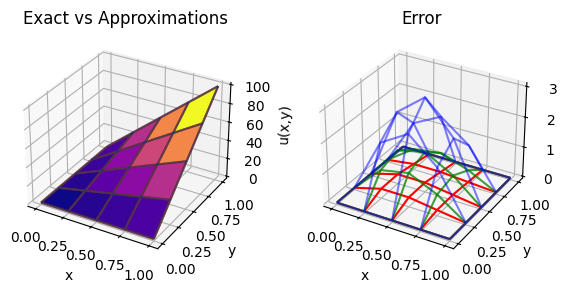

In [2]:
# Problem A
f = lambda x,y: 0
a = 0
b = 1
c = 0
d = 1
def gA(x,y):
    g = 0
    if x == 0:
        g = 0
    if y == 0:
        g = 0
    if x == 1:
        g = 100*y
    if y == 1:
        g = 100*x
    return g
def uA(x,y):
    return 100*x*y
# h = .25
x1,y1,approx1 = poisson_finite_difference(f,a,b,c,d,gA,h=.25,k=.25)
exact1 = uA(*np.meshgrid(x1,y1))
error1 = abs(exact1-approx1)
# h = .125
x2,y2,approx2 = poisson_finite_difference(f,a,b,c,d,gA,h=.125,k=.125)
exact2 = uA(*np.meshgrid(x2,y2))
error2 = abs(exact2-approx2)
# h = .0625
x3,y3,approx3 = poisson_finite_difference(f,a,b,c,d,gA,h=.0625,k=.0625)
exact3 = uA(*np.meshgrid(x3,y3))
error3 = abs(exact3-approx3)

# Dataframe for results
gridx, gridy = np.meshgrid(x1,y1)
dfA = pd.DataFrame({
    "x": gridx.flatten(),
    "y": gridy.flatten(),
    "u(x,y)": exact1.flatten(),
    "w, h=.25": approx1.flatten(),
    "Error, h=.25": error1.flatten(),
    "w, h=.125": approx2[::2, ::2].flatten(),
    "Error, h=.125": error2[::2, ::2].flatten(),
    "w, h=.0625": approx3[::4, ::4].flatten(),
    "Error, h=.0625": error3[::4, ::4].flatten(),
})
dfA

# Plots
plotA = plt.figure(figsize=(7,3))
p1 = plotA.add_subplot(121,projection='3d')
p1.plot_surface(gridx,gridy,exact1, cmap='plasma', alpha=1)
p1.plot_wireframe(gridx,gridy,approx1, color='red', alpha=.75)
p1.plot_wireframe(gridx,gridy,approx2[::2, ::2], color='green', alpha=.5)
p1.plot_wireframe(gridx,gridy,approx3[::4, ::4], color='blue', alpha=.25)
p1.set_title('Exact vs Approximations')
p1.set_xlabel('x')
p1.set_ylabel('y')
p1.set_zlabel('u(x,y)')
p2 = plotA.add_subplot(122,projection='3d')
p2.plot_wireframe(gridx,gridy,error1, color='red', alpha=1)
p2.plot_wireframe(gridx,gridy,error2[::2, ::2],color='green', alpha=.75)
p2.plot_wireframe(gridx,gridy,error3[::4, ::4], color='blue', alpha=.5)
p2.set_title('Error')
p2.set_xlabel('x')
p2.set_ylabel('y')
p2.set_zlabel('Absolute Error')

Text(0.5, 0, 'Absolute Error')

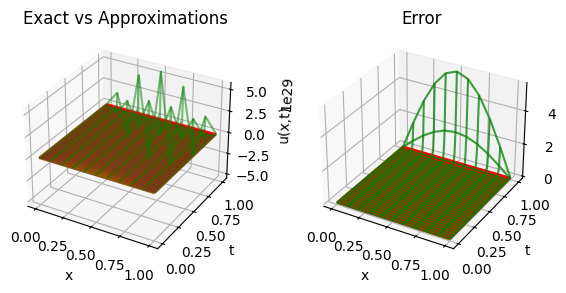

In [35]:
# Problem B (Forward Difference)
alpha = 1
L = 1
f = lambda x: np.sin(np.pi*x)
uB = lambda x,t: np.exp(-(np.pi**2)*t)*np.sin(np.pi*x)
# Forward-difference Stable case
h = .1
k=.0025
x1,t1,approx1 = forward_difference(alpha,L,f,h,k)
exact1 = uB(*np.meshgrid(x1,t1))
error1 = abs(exact1.T -approx1)
# Forward-difference Unstable case
k = .01
x2,t2,approx2 = forward_difference(alpha,L,f,h,k)
exact2 = uB(*np.meshgrid(x2,t2))
error2 = abs(exact2.T -approx2)
# Results Dataframe
dfB = pd.DataFrame({
    "x": x1,
    "u(x,1)": uB(x1,1),
    "w(x,1), k =.0025": approx1[:,-1],
    "Error, k=.0025": error1[:,-1],
    "w(x,1), k =.01": approx2[:,-1],
    "Error, k=.01": error2[:,-1]
})
dfB
#Plots
gridx1, gridt1 = np.meshgrid(x1,t1)
gridx2, gridt2 = np.meshgrid(x2,t2)
plotB= plt.figure(figsize=(7,3))
p1 = plotB.add_subplot(121,projection='3d')
p1.plot_surface(gridx1,gridt1,exact1, cmap='plasma', alpha=1)
p1.plot_wireframe(gridx1,gridt1,approx1.T, color='red', alpha=.75)
p1.plot_wireframe(gridx2,gridt2,approx2.T, color='green', alpha=.5)
p1.set_title('Exact vs Approximations')
p1.set_xlabel('x')
p1.set_ylabel('t')
p1.set_zlabel('u(x,t)')
p2 = plotB.add_subplot(122,projection='3d')
p2.plot_wireframe(gridx1,gridt1,error1.T, color='red', alpha=1)
p2.plot_wireframe(gridx2,gridt2,error2.T,color='green', alpha=.75)
p2.set_title('Error')
p2.set_xlabel('x')
p2.set_ylabel('t')
p2.set_zlabel('Absolute Error')

Text(0.5, 0, 'Absolute Error')

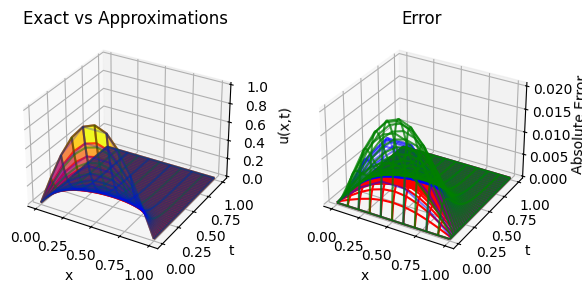

In [36]:
# Problem B (Backward Difference)
# Case 1
h = .1
k=.0025
x1,t1,approx1 = backward_difference(alpha,L,f,h,k)
exact1 = uB(*np.meshgrid(x1,t1))
error1 = abs(exact1.T -approx1)
# Case 2
k = .01
x2,t2,approx2 = backward_difference(alpha,L,f,h,k)
exact2 = uB(*np.meshgrid(x2,t2))
error2 = abs(exact2.T -approx2)
# Case 3
h = .2
k = .0025
x3,t3,approx3 = backward_difference(alpha,L,f,h,k)
exact3 = uB(*np.meshgrid(x3,t3))
error3 = abs(exact3.T -approx3)
# Results Dataframe
dfB = pd.DataFrame({
    "x": x1[::2],
    "u(x,1)": uB(x1,1)[::2],
    "w(x,1), h=.1,k=.0025": approx1[::2,-1],
    "Error, h=.1,k=.0025": error1[::2,-1],
    "w(x,1), h=.1,k =.01": approx2[::2,-1],
    "Error, h=.1,k=.01": error2[::2,-1],
    "w(x,1), h=.2,k=.0025": approx3[:,-1],
    "Error, h=.2,k=.0025": error3[:,-1]
})
dfB
#Plots
gridx1, gridt1 = np.meshgrid(x1,t1)
gridx2, gridt2 = np.meshgrid(x2,t2)
gridx3, gridt3 = np.meshgrid(x3,t3)
plotB= plt.figure(figsize=(7,3))
p1 = plotB.add_subplot(121,projection='3d')
p1.plot_surface(gridx1,gridt1,exact1, cmap='plasma', alpha=1)
p1.plot_wireframe(gridx1,gridt1,approx1.T, color='red', alpha=.75)
p1.plot_wireframe(gridx2,gridt2,approx2.T, color='green', alpha=.5)
p1.plot_wireframe(gridx3,gridt3,approx3.T, color='blue', alpha=.25)
p1.set_title('Exact vs Approximations')
p1.set_xlabel('x')
p1.set_ylabel('t')
p1.set_zlabel('u(x,t)')
p2 = plotB.add_subplot(122,projection='3d')
p2.plot_wireframe(gridx1,gridt1,error1.T, color='red', alpha=1)
p2.plot_wireframe(gridx2,gridt2,error2.T,color='green', alpha=.75)
p2.plot_wireframe(gridx3,gridt3,error3.T, color='blue', alpha=.5)
p2.set_title('Error')
p2.set_xlabel('x')
p2.set_ylabel('t')
p2.set_zlabel('Absolute Error')

Text(0.5, 0, 'Absolute Error')

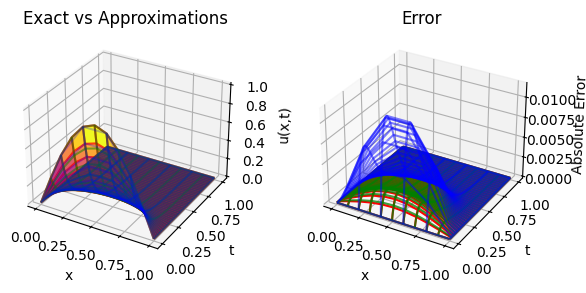

In [37]:
# Problem B (Crank-Nicolson) 
# Case 1
h = .1
k=.0025
x1,t1,approx1 = crank_nicolson(alpha,L,f,h,k)
exact1 = uB(*np.meshgrid(x1,t1))
error1 = abs(exact1.T -approx1)
# Case 2
k = .01
x2,t2,approx2 = crank_nicolson(alpha,L,f,h,k)
exact2 = uB(*np.meshgrid(x2,t2))
error2 = abs(exact2.T -approx2)
# Case 3
h = .2
k = .0025
x3,t3,approx3 = crank_nicolson(alpha,L,f,h,k)
exact3 = uB(*np.meshgrid(x3,t3))
error3 = abs(exact3.T -approx3)
# Results Dataframe
dfB = pd.DataFrame({
    "x": x1[::2],
    "u(x,1)": uB(x1,1)[::2],
    "w(x,1), h=.1,k=.0025": approx1[::2,-1],
    "Error, h=.1,k=.0025": error1[::2,-1],
    "w(x,1), h=.1,k =.01": approx2[::2,-1],
    "Error, h=.1,k=.01": error2[::2,-1],
    "w(x,1), h=.2,k=.0025": approx3[:,-1],
    "Error, h=.2,k=.0025": error3[:,-1]
})
dfB
#Plots
gridx1, gridt1 = np.meshgrid(x1,t1)
gridx2, gridt2 = np.meshgrid(x2,t2)
gridx3, gridt3 = np.meshgrid(x3,t3)
plotB= plt.figure(figsize=(7,3))
p1 = plotB.add_subplot(121,projection='3d')
p1.plot_surface(gridx1,gridt1,exact1, cmap='plasma', alpha=1)
p1.plot_wireframe(gridx1,gridt1,approx1.T, color='red', alpha=.75)
p1.plot_wireframe(gridx2,gridt2,approx2.T, color='green', alpha=.5)
p1.plot_wireframe(gridx3,gridt3,approx3.T, color='blue', alpha=.25)
p1.set_title('Exact vs Approximations')
p1.set_xlabel('x')
p1.set_ylabel('t')
p1.set_zlabel('u(x,t)')
p2 = plotB.add_subplot(122,projection='3d')
p2.plot_wireframe(gridx1,gridt1,error1.T, color='red', alpha=1)
p2.plot_wireframe(gridx2,gridt2,error2.T,color='green', alpha=.75)
p2.plot_wireframe(gridx3,gridt3,error3.T, color='blue', alpha=.5)
p2.set_title('Error')
p2.set_xlabel('x')
p2.set_ylabel('t')
p2.set_zlabel('Absolute Error')

Text(0.5, 0, 'Absolute Error')

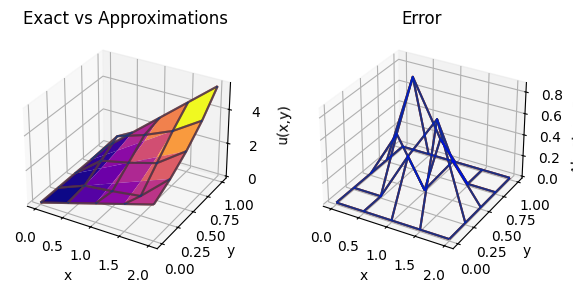

In [3]:
# Problem C: Experiment 1
f = lambda x,y: x*np.exp(y)
a = 0
b = 2
c = 0
d = 1
def gC1(x,y):
    g = 0
    if x == 0:
        g = 0
    if y == 0:
        g = x
    if x == 2:
        g = 2*np.exp(y)
    if y == 1:
        g = np.exp(1)*x
    return g
def uC1(x,y):
    return x*np.exp(y)
# h = .5, k = .25
x1,y1,approx1 = poisson_finite_difference(f,a,b,c,d,gC1,h=.5,k=.25)
exact1 = uC1(*np.meshgrid(x1,y1))
error1 = abs(exact1-approx1)
# h = .25, k = .125
x2,y2,approx2 = poisson_finite_difference(f,a,b,c,d,gC1,h=.25,k=.125)
exact2 = uC1(*np.meshgrid(x2,y2))
error2 = abs(exact2-approx2)
# h = .125, k = .0625
x3,y3,approx3 = poisson_finite_difference(f,a,b,c,d,gC1,h=.125,k=.0625)
exact3 = uC1(*np.meshgrid(x3,y3))
error3 = abs(exact3-approx3)

# Dataframe for results
gridx, gridy = np.meshgrid(x1,y1)
dfC1 = pd.DataFrame({
    "x": gridx.flatten(),
    "y": gridy.flatten(),
    "u(x,y)": exact1.flatten(),
    "w, h=.5, k=.25": approx1.flatten(),
    "Error, h=.5, k=.25": error1.flatten(),
    "w, h=.25, k=.125": approx2[::2, ::2].flatten(),
    "Error, h=.25, k=.125": error2[::2, ::2].flatten(),
    "w, h=.125, k=.0625": approx3[::4, ::4].flatten(),
    "Error, h=.125, k=.0625": error3[::4, ::4].flatten(),
})
dfC1
# Plots
plotC1 = plt.figure(figsize=(7,3))
p1 = plotC1.add_subplot(121,projection='3d')
p1.plot_surface(gridx,gridy,exact1, cmap='plasma', alpha=1)
p1.plot_wireframe(gridx,gridy,approx1, color='red', alpha=.75)
p1.plot_wireframe(gridx,gridy,approx2[::2, ::2], color='green', alpha=.5)
p1.plot_wireframe(gridx,gridy,approx3[::4, ::4], color='blue', alpha=.25)
p1.set_title('Exact vs Approximations')
p1.set_xlabel('x')
p1.set_ylabel('y')
p1.set_zlabel('u(x,y)')
p2 = plotC1.add_subplot(122,projection='3d')
p2.plot_wireframe(gridx,gridy,error1, color='red', alpha=1)
p2.plot_wireframe(gridx,gridy,error2[::2, ::2],color='green', alpha=.75)
p2.plot_wireframe(gridx,gridy,error3[::4, ::4], color='blue', alpha=.5)
p2.set_title('Error')
p2.set_xlabel('x')
p2.set_ylabel('y')
p2.set_zlabel('Absolute Error')

Text(0.5, 0, 'Absolute Error')

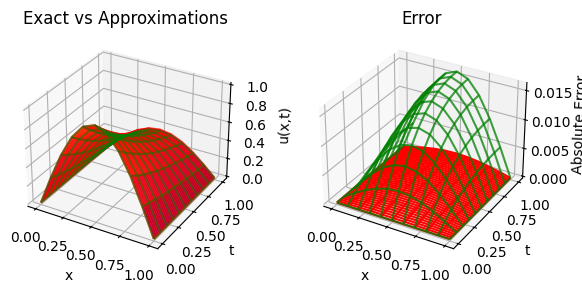

In [9]:
# Problem C: Experiment 2
alpha = 1/np.pi
L = 1
f = lambda x: np.cos(np.pi*(x-.5))
uC2 = lambda x,t: np.exp(-t)*np.cos(np.pi*(x-.5))
# Forward Difference
# Forward-difference Stable case
h = .1
k=.025
x1,t1,approx1 = forward_difference(alpha,L,f,h,k)
exact1 = uC2(*np.meshgrid(x1,t1))
error1 = abs(exact1.T -approx1)
# Forward-difference Unstable case
k = .1
x2,t2,approx2 = forward_difference(alpha,L,f,h,k)
exact2 = uC2(*np.meshgrid(x2,t2))
error2 = abs(exact2.T -approx2)
# Results Dataframe
dfC2 = pd.DataFrame({
    "x": x1,
    "u(x,1)": uC2(x1,1),
    "w(x,1), k =.025": approx1[:,-1],
    "Error, k=.025": error1[:,-1],
    "w(x,1), k =.1": approx2[:,-1],
    "Error, k=.1": error2[:,-1]
})
dfC2
gridx1, gridt1 = np.meshgrid(x1,t1)
gridx2, gridt2 = np.meshgrid(x2,t2)
plotC2= plt.figure(figsize=(7,3))
p1 = plotC2.add_subplot(121,projection='3d')
p1.plot_surface(gridx1,gridt1,exact1, cmap='plasma', alpha=1)
p1.plot_wireframe(gridx1,gridt1,approx1.T, color='red', alpha=.75)
p1.plot_wireframe(gridx2,gridt2,approx2.T, color='green', alpha=.5)
p1.set_title('Exact vs Approximations')
p1.set_xlabel('x')
p1.set_ylabel('t')
p1.set_zlabel('u(x,t)')
p2 = plotC2.add_subplot(122,projection='3d')
p2.plot_wireframe(gridx1,gridt1,error1.T, color='red', alpha=1)
p2.plot_wireframe(gridx2,gridt2,error2.T,color='green', alpha=.75)
p2.set_title('Error')
p2.set_xlabel('x')
p2.set_ylabel('t')
p2.set_zlabel('Absolute Error')

Text(0.5, 0, 'Absolute Error')

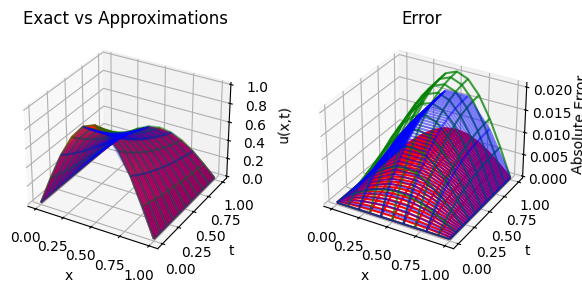

In [11]:
# Problem C2 (Backward Difference)
# Case 1
h = .1
k=.025
x1,t1,approx1 = backward_difference(alpha,L,f,h,k)
exact1 = uC2(*np.meshgrid(x1,t1))
error1 = abs(exact1.T -approx1)
# Case 2
k = .1
x2,t2,approx2 = backward_difference(alpha,L,f,h,k)
exact2 = uC2(*np.meshgrid(x2,t2))
error2 = abs(exact2.T -approx2)
# Case 3
h = .2
k = .025
x3,t3,approx3 = backward_difference(alpha,L,f,h,k)
exact3 = uC2(*np.meshgrid(x3,t3))
error3 = abs(exact3.T -approx3)
# Results Dataframe
dfC2 = pd.DataFrame({
    "x": x1[::2],
    "u(x,1)": uC2(x1,1)[::2],
    "w(x,1), h=.1,k=.025": approx1[::2,-1],
    "Error, h=.1,k=.025": error1[::2,-1],
    "w(x,1), h=.1,k =.1": approx2[::2,-1],
    "Error, h=.1,k=.1": error2[::2,-1],
    "w(x,1), h=.2,k=.025": approx3[:,-1],
    "Error, h=.2,k=.025": error3[:,-1]
})
dfC2
#Plots
gridx1, gridt1 = np.meshgrid(x1,t1)
gridx2, gridt2 = np.meshgrid(x2,t2)
gridx3, gridt3 = np.meshgrid(x3,t3)
plotC2= plt.figure(figsize=(7,3))
p1 = plotC2.add_subplot(121,projection='3d')
p1.plot_surface(gridx1,gridt1,exact1, cmap='plasma', alpha=1)
p1.plot_wireframe(gridx1,gridt1,approx1.T, color='red', alpha=.75)
p1.plot_wireframe(gridx2,gridt2,approx2.T, color='green', alpha=.5)
p1.plot_wireframe(gridx3,gridt3,approx3.T, color='blue', alpha=.25)
p1.set_title('Exact vs Approximations')
p1.set_xlabel('x')
p1.set_ylabel('t')
p1.set_zlabel('u(x,t)')
p2 = plotC2.add_subplot(122,projection='3d')
p2.plot_wireframe(gridx1,gridt1,error1.T, color='red', alpha=1)
p2.plot_wireframe(gridx2,gridt2,error2.T,color='green', alpha=.75)
p2.plot_wireframe(gridx3,gridt3,error3.T, color='blue', alpha=.5)
p2.set_title('Error')
p2.set_xlabel('x')
p2.set_ylabel('t')
p2.set_zlabel('Absolute Error')

Text(0.5, 0, 'Absolute Error')

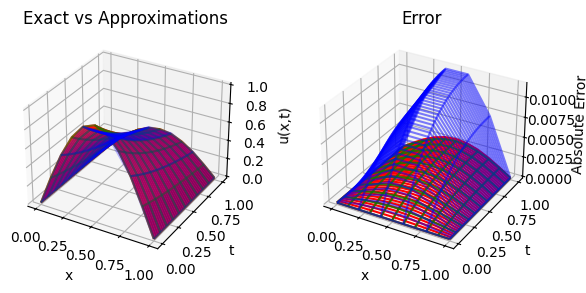

In [13]:
# Problem C2 (Crank-Nicolson)
# Case 1
h = .1
k=.025
x1,t1,approx1 = crank_nicolson(alpha,L,f,h,k)
exact1 = uC2(*np.meshgrid(x1,t1))
error1 = abs(exact1.T -approx1)
# Case 2
k = .1
x2,t2,approx2 = crank_nicolson(alpha,L,f,h,k)
exact2 = uC2(*np.meshgrid(x2,t2))
error2 = abs(exact2.T -approx2)
# Case 3
h = .2
k = .025
x3,t3,approx3 = crank_nicolson(alpha,L,f,h,k)
exact3 = uC2(*np.meshgrid(x3,t3))
error3 = abs(exact3.T -approx3)
# Results Dataframe
dfC2 = pd.DataFrame({
    "x": x1[::2],
    "u(x,1)": uC2(x1,1)[::2],
    "w(x,1), h=.1,k=.025": approx1[::2,-1],
    "Error, h=.1,k=.025": error1[::2,-1],
    "w(x,1), h=.1,k =.1": approx2[::2,-1],
    "Error, h=.1,k=.1": error2[::2,-1],
    "w(x,1), h=.2,k=.025": approx3[:,-1],
    "Error, h=.2,k=.025": error3[:,-1]
})
dfC2
#Plots
gridx1, gridt1 = np.meshgrid(x1,t1)
gridx2, gridt2 = np.meshgrid(x2,t2)
gridx3, gridt3 = np.meshgrid(x3,t3)
plotC2= plt.figure(figsize=(7,3))
p1 = plotC2.add_subplot(121,projection='3d')
p1.plot_surface(gridx1,gridt1,exact1, cmap='plasma', alpha=1)
p1.plot_wireframe(gridx1,gridt1,approx1.T, color='red', alpha=.75)
p1.plot_wireframe(gridx2,gridt2,approx2.T, color='green', alpha=.5)
p1.plot_wireframe(gridx3,gridt3,approx3.T, color='blue', alpha=.25)
p1.set_title('Exact vs Approximations')
p1.set_xlabel('x')
p1.set_ylabel('t')
p1.set_zlabel('u(x,t)')
p2 = plotC2.add_subplot(122,projection='3d')
p2.plot_wireframe(gridx1,gridt1,error1.T, color='red', alpha=1)
p2.plot_wireframe(gridx2,gridt2,error2.T,color='green', alpha=.75)
p2.plot_wireframe(gridx3,gridt3,error3.T, color='blue', alpha=.5)
p2.set_title('Error')
p2.set_xlabel('x')
p2.set_ylabel('t')
p2.set_zlabel('Absolute Error')